In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

excel_path = Path(r"C:\Users\verav\Downloads\pitch_decay_outputs\Pitch_decay_summary_all_constructions.xlsx")
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Pitch_decay_analysis_plots")
output_dir.mkdir(parents=True, exist_ok=True)

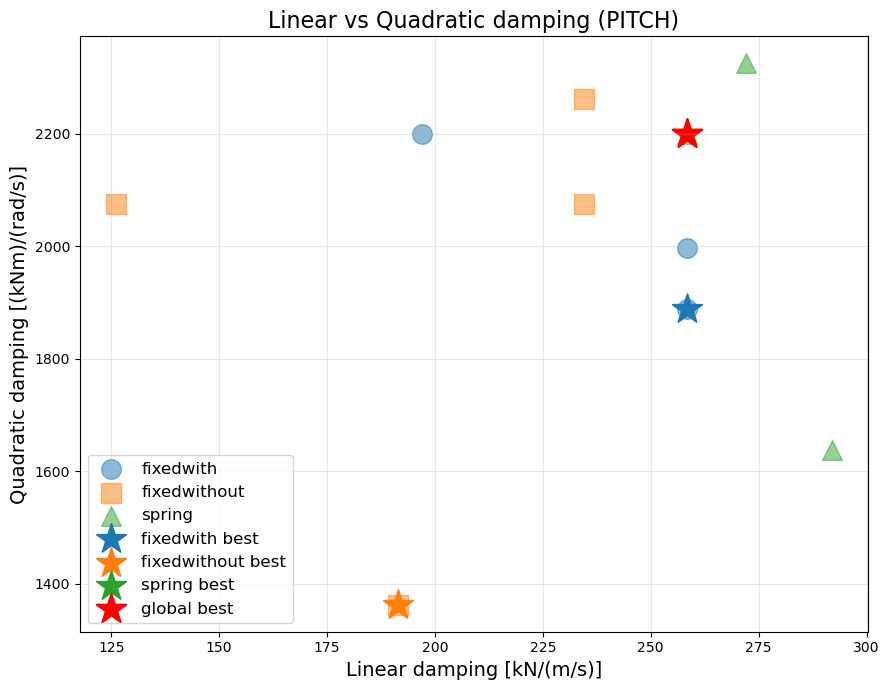

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# INSTELLEN
# =========================
df = pd.read_excel(excel_path, sheet_name="per_test_best")

# =========================
# STIJL
# =========================
marker_map = {
    "fixedwith": "o",
    "fixedwithout": "s",
    "spring": "^"
}

color_map = {
    "fixedwith": "tab:blue",
    "fixedwithout": "tab:orange",
    "spring": "tab:green"
}

def get_marker(construction):
    return marker_map.get(str(construction).lower(), "x")

def get_color(construction):
    return color_map.get(str(construction).lower(), "black")

# =========================
# PLOT
# =========================
plt.figure(figsize=(9, 7))

# --- alle punten ---
for cons in df["construction"].unique():
    sub = df[df["construction"] == cons]

    plt.scatter(
        sub["fine_lin"],
        sub["fine_quad"],
        s=200,
        marker=get_marker(cons),
        color=get_color(cons),
        alpha=0.5,
        label=cons
    )

# --- beste per constructie ---
for cons in df["construction"].unique():
    sub = df[df["construction"] == cons]

    best_idx = sub["RMSE_total"].idxmin()
    best = sub.loc[best_idx]

    plt.scatter(
        best["fine_lin"],
        best["fine_quad"],
        s=500,
        marker="*",
        color=get_color(cons),   # 🔥 zelfde kleur
    
        linewidths=1.2,
        label=f"{cons} best"
    )

# --- globale beste ---
global_best_idx = df["RMSE_total"].idxmin()
global_best = df.loc[global_best_idx]

plt.scatter(
    global_best["fine_lin"],
    global_best["fine_quad"],
    s=500,
    marker="*",
    color="red",                # bewust anders

    linewidths=1.5,
    label="global best"
)

# =========================
# AFWERKING
# =========================
plt.xlabel("Linear damping [kN/(m/s)]", fontsize=LABEL_SIZE)
plt.ylabel("Quadratic damping [(kNm)/(rad/s)]", fontsize=LABEL_SIZE)
plt.title("Linear vs Quadratic damping (PITCH)", fontsize=TITLE_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()

plt.show()

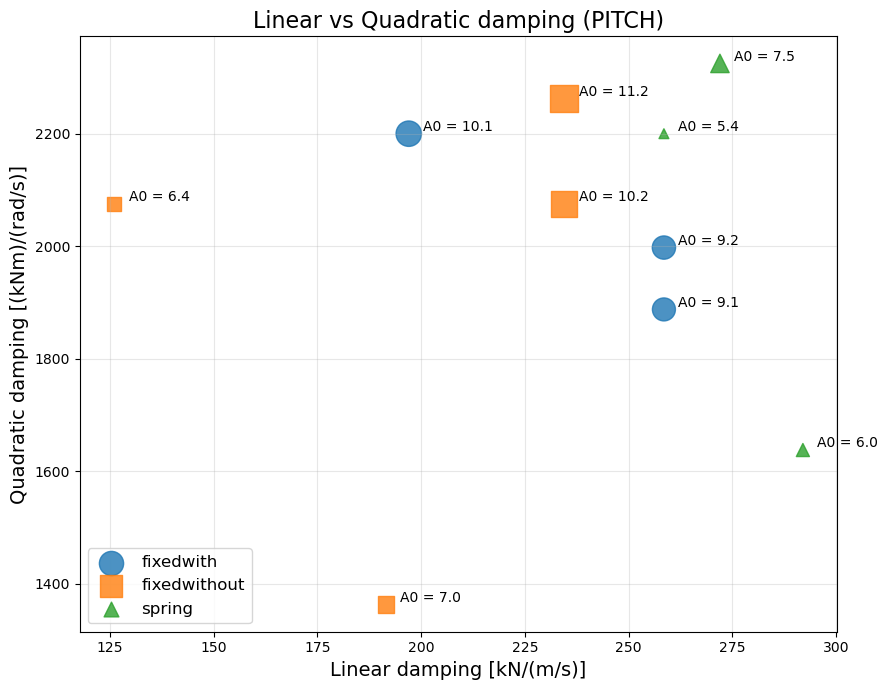

In [30]:
import numpy as np

amp_col = "A0_abs [deg]"
amp = df[amp_col].values

# =========================
# SIZE SCHALING
# =========================
if np.max(amp) - np.min(amp) < 1e-6:
    sizes = np.full_like(amp, 200)
else:
    sizes = 50 + 350 * (amp - np.min(amp)) / (np.max(amp) - np.min(amp))

df["marker_size"] = sizes

# =========================
# PLOT
# =========================
plt.figure(figsize=(9, 7))

for cons in df["construction"].unique():
    sub = df[df["construction"] == cons]

    plt.scatter(
        sub["fine_lin"],
        sub["fine_quad"],
        s=sub["marker_size"],
        marker=get_marker(cons),
        color=get_color(cons),
        alpha=0.8,
        label=cons
    )

    # 🔥 kleine amplitude labels
    for _, row in sub.iterrows():
        plt.text(
            row["fine_lin"] + 3.5,   # kleine shift in x
            row["fine_quad"] + 5,  # kleine shift in y
            f"A0 = {row[amp_col]:.1f}",
            fontsize=10,
            alpha=1
        )

# =========================
# AFWERKING
# =========================
plt.xlabel("Linear damping [kN/(m/s)]", fontsize=LABEL_SIZE)
plt.ylabel("Quadratic damping [(kNm)/(rad/s)]", fontsize=LABEL_SIZE)
plt.title("Linear vs Quadratic damping (PITCH)", fontsize=TITLE_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()

plt.show()

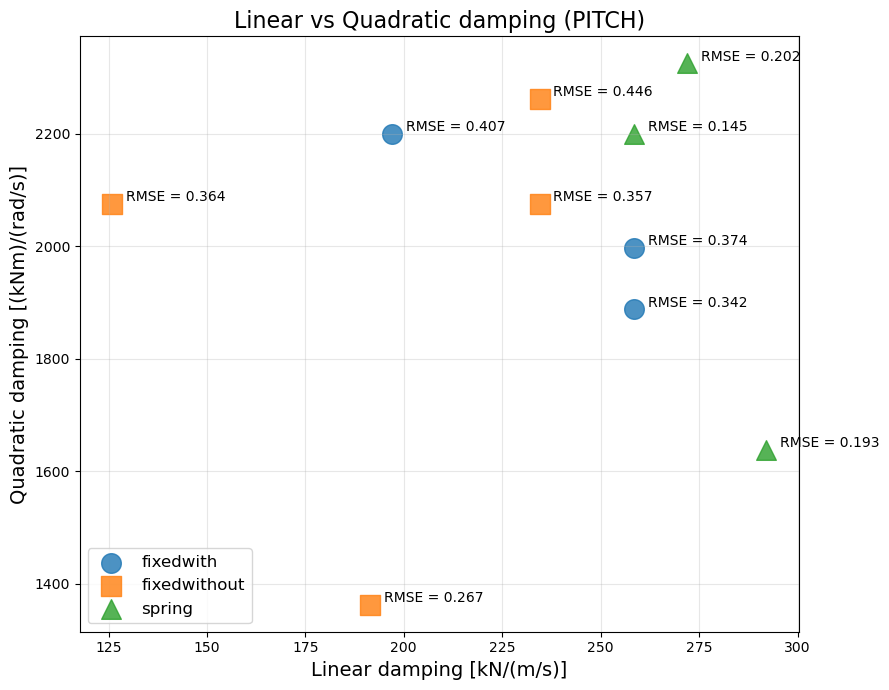

In [34]:
import numpy as np

amp_col = "A0_abs [deg]"
amp = df[amp_col].values

# =========================
# SIZE SCHALING
# =========================
if np.max(amp) - np.min(amp) < 1e-6:
    sizes = np.full_like(amp, 200)
else:
    sizes = 50 + 350 * (amp - np.min(amp)) / (np.max(amp) - np.min(amp))

df["marker_size"] = sizes

# =========================
# PLOT
# =========================
plt.figure(figsize=(9, 7))

for cons in df["construction"].unique():
    sub = df[df["construction"] == cons]

    plt.scatter(
        sub["fine_lin"],
        sub["fine_quad"],
        marker=get_marker(cons),
        color=get_color(cons),
        s = 200,
        alpha=0.8,
        label=cons
    )

    # 🔥 kleine amplitude labels
    for _, row in sub.iterrows():
        plt.text(
            row["fine_lin"] + 3.5,   # kleine shift in x
            row["fine_quad"] + 5,  # kleine shift in y
            f"RMSE = {row['RMSE_total']:.3f}",
            fontsize=10,
            alpha=1
        )

# =========================
# AFWERKING
# =========================
plt.xlabel("Linear damping [kN/(m/s)]", fontsize=LABEL_SIZE)
plt.ylabel("Quadratic damping [(kNm)/(rad/s)]", fontsize=LABEL_SIZE)
plt.title("Linear vs Quadratic damping (PITCH)", fontsize=TITLE_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()

plt.show()

In [42]:
import pandas as pd
import numpy as np

# ==========================================
# INLEZEN
# ==========================================
df_per_test = pd.read_excel(excel_path, sheet_name="per_test_best")
df_construction_winners = pd.read_excel(excel_path, sheet_name="construction_winners")
df_global_winner_runs = pd.read_excel(excel_path, sheet_name="global_winner_runs")

# ==========================================
# TABEL 1
# GEMIDDELDE VAN IEDEREENS EIGEN BESTE FIT
# ==========================================
table1 = (
    df_per_test
    .groupby("construction")
    .agg(
        N_tests=("RMSE_total", "size"),
        Mean_RMSE_own_best=("RMSE_total", "mean"),
        Std_RMSE_own_best=("RMSE_total", "std"),
        Min_RMSE_own_best=("RMSE_total", "min"),
        Max_RMSE_own_best=("RMSE_total", "max"),
    )
    .reset_index()
)

# ==========================================
# TABEL 2
# BESTE FIT PER CONSTRUCTIE OP ALLE TESTEN
# VAN DIE CONSTRUCTIE
# ==========================================
table2_cols = [c for c in [
    "construction_scope",
    "winner_lin",
    "winner_quad",
    "mean_RMSE_total",
    "mean_RMSE_peaks",
    "mean_RMSE_troughs"
] if c in df_construction_winners.columns]

table2 = df_construction_winners[table2_cols].copy()

table2 = table2.rename(columns={
    "construction_scope": "construction",
    "winner_lin": "Best_lin",
    "winner_quad": "Best_quad",
    "mean_RMSE_total": "Mean_RMSE_construction_best",
    "mean_RMSE_peaks": "Mean_RMSE_peaks",
    "mean_RMSE_troughs": "Mean_RMSE_troughs"
})

# ==========================================
# TABEL 3
# GLOBALE BESTE FIT OP ALLE DATA
# ==========================================
table3 = pd.DataFrame({
    "Metric": [
        "N tests",
        "Mean RMSE",
        "Std RMSE",
        "Min RMSE",
        "Max RMSE"
    ],
    "Value": [
        len(df_global_winner_runs),
        df_global_winner_runs["RMSE_total"].mean(),
        df_global_winner_runs["RMSE_total"].std(),
        df_global_winner_runs["RMSE_total"].min(),
        df_global_winner_runs["RMSE_total"].max(),
    ]
})

if "winner_lin" in df_global_winner_runs.columns and "winner_quad" in df_global_winner_runs.columns:
    best_lin = df_global_winner_runs["winner_lin"].iloc[0]
    best_quad = df_global_winner_runs["winner_quad"].iloc[0]

    extra = pd.DataFrame({
        "Metric": ["Best lin", "Best quad"],
        "Value": [best_lin, best_quad]
    })

    table3 = pd.concat([extra, table3], ignore_index=True)

# ==========================================
# AFRONDEN
# ==========================================
def round_numeric(df, decimals=3):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(decimals)
    return out

table1 = round_numeric(table1, 3)
table2 = round_numeric(table2, 3)
table3 = round_numeric(table3, 3)

print("\n=== TABLE 1: MEAN OF EACH TEST'S OWN BEST FIT ===")
print(table1)

print("\n=== TABLE 2: BEST FIT PER CONSTRUCTION APPLIED TO THAT CONSTRUCTION ===")
print(table2)

print("\n=== TABLE 3: GLOBAL BEST FIT APPLIED TO ALL DATA ===")
print(table3)


=== TABLE 1: MEAN OF EACH TEST'S OWN BEST FIT ===
   construction  N_tests  Mean_RMSE_own_best  Std_RMSE_own_best  \
0     fixedwith        3               0.374              0.032   
1  fixedwithout        4               0.358              0.073   
2        spring        3               0.180              0.031   

   Min_RMSE_own_best  Max_RMSE_own_best  
0              0.342              0.407  
1              0.267              0.446  
2              0.145              0.202  

=== TABLE 2: BEST FIT PER CONSTRUCTION APPLIED TO THAT CONSTRUCTION ===
   construction  Best_lin  Best_quad  Mean_RMSE_construction_best
0     fixedwith     258.5     1887.5                        0.380
1  fixedwithout     234.5     2075.0                        0.420
2        spring     258.5     2200.0                        0.183

=== TABLE 3: GLOBAL BEST FIT APPLIED TO ALL DATA ===
      Metric     Value
0   Best lin   258.500
1  Best quad  1887.500
2    N tests    10.000
3  Mean RMSE     0.349
4   St